# LINDA VASQUEZ Clasificador de Imagenes

In [2]:
import os
import shutil

ruta_train = "/workspaces/LIVASQUE_Clasificador_de_Imagenes/data/raw/dogs-vs-cats/train" 

print(f"Python está buscando en: {ruta_train}")

if not os.path.exists(ruta_train):
    print("Python dice que esta ruta no existe. Revisa que esté bien pegada.")
else:
    # Conteo de .jpg
    archivos = [f for f in os.listdir(ruta_train) if f.endswith('.jpg')]
    print(f"Python logró ver {len(archivos)} fotos .jpg en esta carpeta")
    
    # Crear las rutas de las nuevas carpetas
    if len(archivos) > 0:
        ruta_dog = os.path.join(ruta_train, "dog")
        ruta_cat = os.path.join(ruta_train, "cat")
        
        os.makedirs(ruta_dog, exist_ok=True)
        os.makedirs(ruta_cat, exist_ok=True)
        
        for archivo in archivos:
            ruta_origen = os.path.join(ruta_train, archivo)
            
            if "dog" in archivo.lower():
                shutil.move(ruta_origen, os.path.join(ruta_dog, archivo))
            elif "cat" in archivo.lower():
                shutil.move(ruta_origen, os.path.join(ruta_cat, archivo))
                
        print("Las fotos han sido ordenadas y separadas")

Python está buscando en: /workspaces/LIVASQUE_Clasificador_de_Imagenes/data/raw/dogs-vs-cats/train
Python logró ver 0 fotos .jpg en esta carpeta


In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

carpeta_datos = "/workspaces/LIVASQUE_Clasificador_de_Imagenes/data/raw/dogs-vs-cats/train"
tamano_foto = (200, 200)

generador_imagenes = ImageDataGenerator(
    rescale=1./255, 
    validation_split=0.2 # 20% para pruebas
)

print("Cargando datos de entrenamiento...")
datos_entrenamiento = generador_imagenes.flow_from_directory(
    carpeta_datos,
    target_size=tamano_foto,
    classes=["dog", "cat"],
    batch_size=8,
    subset='training' # 80% de estudio
)

print("Cargando datos de prueba (validacion)...")
datos_prueba = generador_imagenes.flow_from_directory(
    carpeta_datos,
    target_size=tamano_foto,
    classes=["dog", "cat"],
    batch_size=32,
    subset='validation' # 20% de examen
)

Cargando datos de entrenamiento...
Found 20000 images belonging to 2 classes.
Cargando datos de prueba (validacion)...
Found 5000 images belonging to 2 classes.


## Red Neuronal

In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPool2D, Flatten

modelo = Sequential()

# menos filtros (32, 64, 128) porque mi maquina no esta soportando:C
modelo.add(Conv2D(input_shape=(200, 200, 3), filters=32, kernel_size=(3,3), padding="same", activation="relu"))
modelo.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

modelo.add(Conv2D(filters=64, kernel_size=(3,3), padding="same", activation="relu"))
modelo.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

modelo.add(Conv2D(filters=128, kernel_size=(3,3), padding="same", activation="relu"))
modelo.add(MaxPool2D(pool_size=(2,2), strides=(2,2)))

modelo.add(Flatten())

# De 4096 a 256 neuronas
modelo.add(Dense(units=256, activation="relu"))
modelo.add(Dense(units=2, activation="softmax"))

modelo.summary()

/home/vscode/.local/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1779938192.254609   25690 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
W0000 00:00:1779938192.340582   25690 cpu_allocator_impl.cc:82] Allocation of 81920000 exceeds 10% of free system memory.
W0000 00:00:1779938192.482517   25690 cpu_allocator_impl.cc:82] Allocation of 81920000 exceeds 10% of free system memory.
W0000 00:00:1779938192.553083   25690 cpu_allocator_impl.cc:82] Allocation of 81920000 exceeds 10% of free system memory.


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 200, 200, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 100, 100, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 100, 100, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 80000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    20,480,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,574,018 (78.48 MB)

 Trainable params: 20,574,018 (78.48 MB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [5]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

modelo.compile(
    loss="categorical_crossentropy", 
    optimizer=Adam(learning_rate=0.001), 
    metrics=["accuracy"]
)

carpeta_modelos = "/workspaces/LIVASQUE_Clasificador_de_Imagenes/models"
os.makedirs(carpeta_modelos, exist_ok=True)
ruta_guardado = os.path.join(carpeta_modelos, "modelo_gatos_perros.keras")

punto_guardado = ModelCheckpoint(
    filepath=ruta_guardado, 
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

parada_temprana = EarlyStopping(
    monitor="val_accuracy", 
    patience=3, # 3 intentos maximo para mejorar la nota
    verbose=1
)

print("Iniciando entrenamiento de la red neuronal...")
historial = modelo.fit(
    datos_entrenamiento,
    validation_data=datos_prueba,
    epochs=5, 
    steps_per_epoch=20,
    validation_steps=5,
    callbacks=[punto_guardado, parada_temprana]
)

Iniciando entrenamiento de la red neuronal...
Epoch 1/5


I0000 00:00:1779938207.273657   25690 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
W0000 00:00:1779938207.965614   25690 cpu_allocator_impl.cc:82] Allocation of 81920000 exceeds 10% of free system memory.
W0000 00:00:1779938208.495507   26118 cpu_allocator_impl.cc:82] Allocation of 40960000 exceeds 10% of free system memory.


20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 695ms/step - accuracy: 0.5246 - loss: 1.1930
Epoch 1: val_accuracy improved from None to 0.48750, saving model to /workspaces/LIVASQUE_Clasificador_de_Imagenes/models/modelo_gatos_perros.keras

Epoch 1: finished saving model to /workspaces/LIVASQUE_Clasificador_de_Imagenes/models/modelo_gatos_perros.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 944ms/step - accuracy: 0.5375 - loss: 0.9651 - val_accuracy: 0.4875 - val_loss: 0.7386
Epoch 2/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 846ms/step - accuracy: 0.4488 - loss: 0.7217
Epoch 2: val_accuracy did not improve from 0.48750
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 1s/step - accuracy: 0.4437 - loss: 0.7030 - val_accuracy: 0.4688 - val_loss: 0.6934
Epoch 3/5
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 630ms/step - accuracy: 0.5161 - loss: 0.6937
Epoch 3: val_accuracy improved from 0.48750 to 0.57500, saving model to /workspaces/LIVASQUE_Clasificador_de_Imagenes/models/modelo_gatos_perros.keras

Epoch 3: finished saving model to /workspaces/LIVASQUE_Cl

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/vscode/.local/lib/python3.11/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/home/vscode/.local/lib/python3.11/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/home/vscode/.local/lib/python3.11/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = se

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step


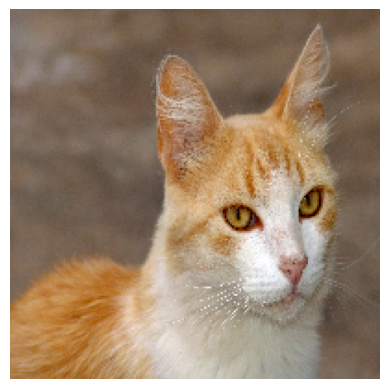

El modelo está 50.20% seguro de que es un gato


Bad pipe message: %s [b"Ql\xeb\x0c\xe4\xb8\xd7(\x8br\x1a\xe1U\x12\xd6B\xa5\xac\x00\x00\x84\x003\x009\x005\x00/\xc0,\xc00\x00\xa3\x00\x9f\xcc\xa9\xcc\xa8\xcc\xaa\xc0\xaf\xc0\xad\xc0\xa3\xc0\x9f\xc0+\xc0/\x00\xa2\x00\x9e\xc0\xae\xc0\xac\xc0\xa2\xc0\x9e\xc0$\xc0(\x00k\x00j\xc0s\xc0w\x00\xc4\x00\xc3\xc0#\xc0'\x00g\x00@\xc0r\xc0v\x00\xbe\x00\xbd\xc0\n\xc0\x14\x008\x00\x88\x00\x87\xc0\t\xc0\x13\x002\x00\x9a\x00\x99\x00E\x00D\x00\x9d\xc0\xa1\xc0\x9d\x00\x9c\xc0\xa0\xc0\x9c\x00=\x00\xc0\x00<\x00\xba\x00\x84\x00\x96\x00A\x00\x07\x00\xff\x01\x00\x00F\x00\x0b\x00\x04\x03\x00\x01\x02\x00\n\x00\n\x00\x08\x00\x1d"]
Bad pipe message: %s [b'\x85\x9b\x845_\x11\x10](\x07\x80(n\x00\x8c\x81\xc8\xe6\x00\x00\x80\xc0\x9f\xc0\xa3\x00\x9f\xc0D\xc0R\xc0E\xc0S\x00E\x00\xbe\xc0|\x00\x88\x00\xc4\xc0}\xcc\xaa\xcc\x15\x00\x15\x00\x9a\x00\x0b\x00\r\x000\x00>\x00\xa4\x006\x00h\x00\xa5\xc0>\xc0X\xc0?\xc0Y\x00B\x00\xbb\xc0\x82\x00\x85\x00\xc1\xc0\x83\x00\x0c\x00\x97\x00\x0e\x00\x10\x001\x00']
Bad pipe message: %s [b'\xa

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

ruta_modelo = "/workspaces/LIVASQUE_Clasificador_de_Imagenes/models/modelo_gatos_perros.keras"
modelo_guardado = load_model(ruta_modelo)

ruta_foto = "/workspaces/LIVASQUE_Clasificador_de_Imagenes/data/Gato_(2)_REFON.jpg"

foto_prueba = image.load_img(ruta_foto, target_size=(200, 200)) # Ajuste tamaño
foto_arreglo = image.img_to_array(foto_prueba) # conv a números
foto_arreglo = foto_arreglo / 255.0
foto_lista = np.expand_dims(foto_arreglo, axis=0)

prediccion = modelo_guardado.predict(foto_lista)

# foto en pantalla
plt.imshow(foto_prueba)
plt.axis('off')
plt.show()

probabilidad_perro = prediccion[0][0] * 100
probabilidad_gato = prediccion[0][1] * 100

if probabilidad_perro > probabilidad_gato:
    print(f"El modelo está {probabilidad_perro:.2f}% seguro de que es un perro")
else:
    print(f"El modelo está {probabilidad_gato:.2f}% seguro de que es un gato")